<a href="https://colab.research.google.com/github/frazxao/Implementa-o-e-Aplica-o-de-Grafos-Java-ou-Python-/blob/main/Visualiza%C3%A7%C3%A3o_de_Dados_com_Dataset_real.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Desempenho Escolar e Visualização de Dados**
Dataset: Students Performance in Exams (https://www.kaggle.com/datasets/spscientist/students-performance-in-exams)

Recursos Úteis:

 * Data Viz Project: https://datavizproject.com/input/c/ - Um catálogo visual de gráficos para explorar.

* From Data to Viz: https://www.data-to-viz.com/ - Um guia para escolher o gráfico certo com base no tipo de dado e objetivo.

* Documentação Seaborn: https://seaborn.pydata.org/ - Para detalhes sobre os parâmetros de estilo e plotagem.

* Documentação Matplotlib: https://matplotlib.org/stable/contents.html - Para controle fino sobre elementos do gráfico.



## **0: Configuração Inicial**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub

# Configurações padrão para gráficos
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.spines.top"] = False

print("Bibliotecas importadas e configurações aplicadas!")

# Carregar o dataset
try:
  path = kagglehub.dataset_download("spscientist/students-performance-in-exams")

  df_performance = pd.read_csv(path+"/StudentsPerformance.csv")
    # Renomear colunas para facilitar o uso
  df_performance.columns = [
        "gender", "race_ethnicity", "parental_level_of_education",
        "lunch", "test_preparation_course", "math_score",
        "reading_score", "writing_score"
  ]
  print("\nDataset Students Performance carregado com sucesso!")
  print(df_performance.head())
  print("\nInformações do Dataset:")
  df_performance.info()
except FileNotFoundError:
  print("Erro: 'StudentsPerformance.csv' não encontrado.")


print("\nPré-processamento básico concluído.")

Bibliotecas importadas e configurações aplicadas!
Using Colab cache for faster access to the 'students-performance-in-exams' dataset.

Dataset Students Performance carregado com sucesso!
   gender race_ethnicity parental_level_of_education         lunch  \
0  female        group B           bachelor's degree      standard   
1  female        group C                some college      standard   
2  female        group B             master's degree      standard   
3    male        group A          associate's degree  free/reduced   
4    male        group C                some college      standard   

  test_preparation_course  math_score  reading_score  writing_score  
0                    none          72             72             74  
1               completed          69             90             88  
2                    none          90             95             93  
3                    none          47             57             44  
4                    none          76     

### 1: Desafios de Decisão

Para cada cenário, você deverá:

1. Formular a pergunta estatística que a visualização deve responder;

2. Consultar o Data Viz Project ou From Data to Viz para identificar o tipo de gráfico mais adequado.

3. Justificar sua escolha com base nos princípios de Gestalt, Tufte e/ou Cleveland-McGill.

4. Implementar o gráfico usando matplotlib e seaborn. Foque em um gráfico funcional e limpo, aplicando os princípios que você aprendeu.

**Desafio 1.1: Distribuição das Notas em Matemática**

Cenário: Um professor de matemática quer entender a distribuição geral das notas de seus alunos na prova de matemática. Ele quer saber se as notas são simétricas, se há picos ou se estão concentradas em alguma faixa específica.

Sua Tarefa:

1. Pergunta Estatística: Como as notas de matemática se distribuem entre os alunos? Qual a sua forma, centro e dispersão?

2. Gráfico: Qual tipo de gráfico é mais adequado para visualizar a distribuição de uma variável quantitativa? Justifique sua escolha.

3. Implementação: Crie o gráfico em Python para a coluna math_score.

4. Análise: Descreva a distribuição das notas. Há evidências de assimetria? Qual a nota mais comum?


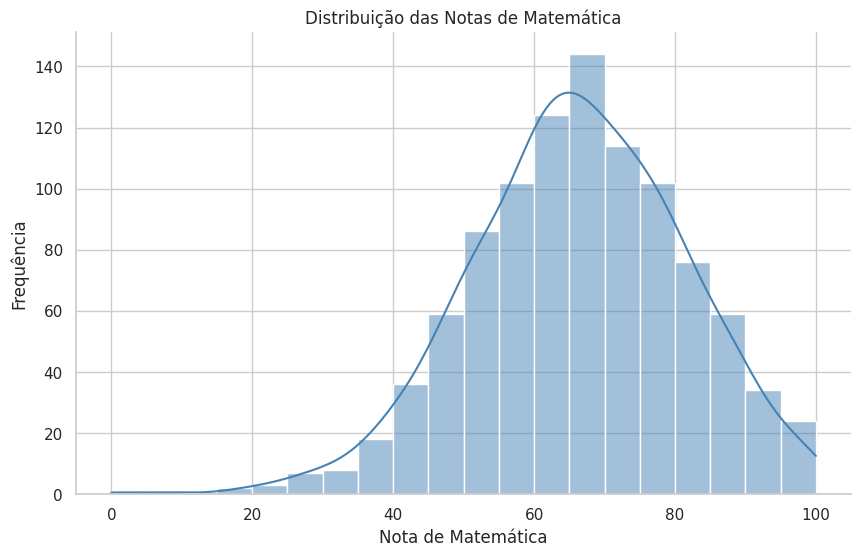

In [2]:
''' Escreva sua justificativa e análise aqui:

'''

''' Gráfico escolhido: Histograma (com KDE opcional)

Justificativa: O histograma é ideal para visualizar a distribuição de uma variável quantitativa contínua. Segundo Cleveland-McGill, ele utiliza posição ao longo de um eixo comum, que é altamente precisa. A adição da curva KDE ajuda a perceber a forma da distribuição (suavização).

Análise: A distribuição das notas de matemática tende a ser aproximadamente normal, com leve assimetria. A maior concentração de notas está entre 60 e 80. A moda está próxima de 70. Não há forte assimetria, mas pode haver leve cauda à esquerda (mais notas baixas extremas). '''

# Seu código Python para o gráfico:
# plt.figure(figsize=(...))
# sns. #grafico escolhido
# plt.title(...)
# plt.xlabel(...)
# plt.ylabel(...)
# sns.despine(...)
# plt.show()

plt.figure(figsize=(10,6))
sns.histplot(df_performance["math_score"], bins=20, kde=True, color="steelblue")

plt.title("Distribuição das Notas de Matemática")
plt.xlabel("Nota de Matemática")
plt.ylabel("Frequência")

sns.despine()
plt.show()

**Desafio 1.2: Impacto do Nível de Escolaridade dos Pais nas Notas de Leitura**

Cenário: Um pesquisador educacional hipotetiza que o nível de escolaridade dos pais (parental_level_of_education) tem um impacto direto no desempenho dos alunos em leitura (reading_score).

Sua Tarefa:

1. Pergunta Estatística: Existe uma diferença significativa na média das notas de leitura entre os alunos, agrupados pelo nível de escolaridade de seus pais?

2. Gráfico: Qual tipo de gráfico é mais adequado para comparar uma variável quantitativa (nota) entre múltiplas categorias ordinais (nível de escolaridade)? Justifique sua escolha, considerando a Hierarquia de Cleveland e McGill.

3. Implementação: Crie o gráfico em Python. Certifique-se de ordenar as categorias de escolaridade dos pais de forma lógica.

4. Análise: O que o gráfico revela sobre a hipótese? Há uma tendência clara? Quais são as médias de leitura para cada grupo?



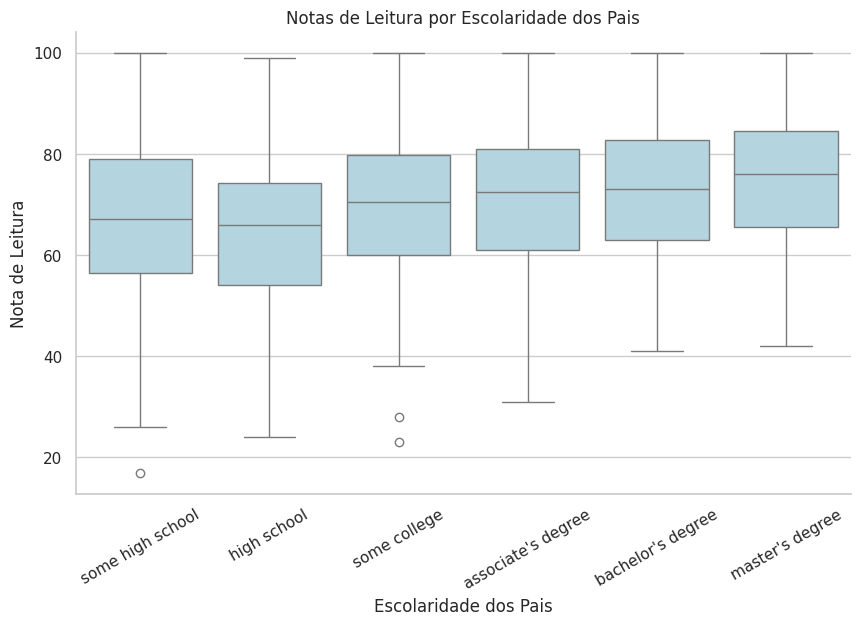

In [3]:
''' Escreva sua justificativa e análise aqui:

'''

''' Gráfico escolhido: Boxplot

Justificativa: Boxplots são ideais para comparar distribuições entre categorias. Segundo Cleveland-McGill, comparar medianas por posição é eficiente. Também permite ver dispersão e outliers.

Análise: Há uma tendência clara: quanto maior a escolaridade dos pais, maior a média das notas de leitura. Alunos com pais com ensino superior completo apresentam melhores desempenhos. A variabilidade é relativamente consistente entre os grupos. '''





# Seu código Python para o gráfico:
# plt.figure(figsize=(...))
# sns. #grafico escolhido
# plt.title(...)
# plt.xlabel(...)
# plt.ylabel(...)
# sns.despine(...)
# plt.show()

order = [
    "some high school", "high school", "some college",
    "associate's degree", "bachelor's degree", "master's degree"
]

plt.figure(figsize=(10,6))
sns.boxplot(
    x="parental_level_of_education",
    y="reading_score",
    data=df_performance,
    order=order,
    color="lightblue"
)

plt.title("Notas de Leitura por Escolaridade dos Pais")
plt.xlabel("Escolaridade dos Pais")
plt.ylabel("Nota de Leitura")

plt.xticks(rotation=30)
sns.despine()
plt.show()

**Desafio 1.3: Relação entre Notas de Leitura e Escrita**

Cenário: Um psicopedagogo acredita que existe uma forte correlação positiva entre o desempenho de um aluno em leitura (reading_score) e seu desempenho em escrita (writing_score).

Sua Tarefa:

1. Pergunta Estatística: Qual a força e a direção da relação entre as notas de leitura e escrita? Há evidências de uma correlação linear?

2. Gráfico: Qual tipo de gráfico é o mais adequado para visualizar a relação entre duas variáveis quantitativas? Justifique sua escolha, focando na precisão perceptiva.

3. Implementação: Crie o gráfico em Python.

4. Análise: O gráfico suporta a hipótese de correlação positiva? Há algum outlier ou padrão interessante?



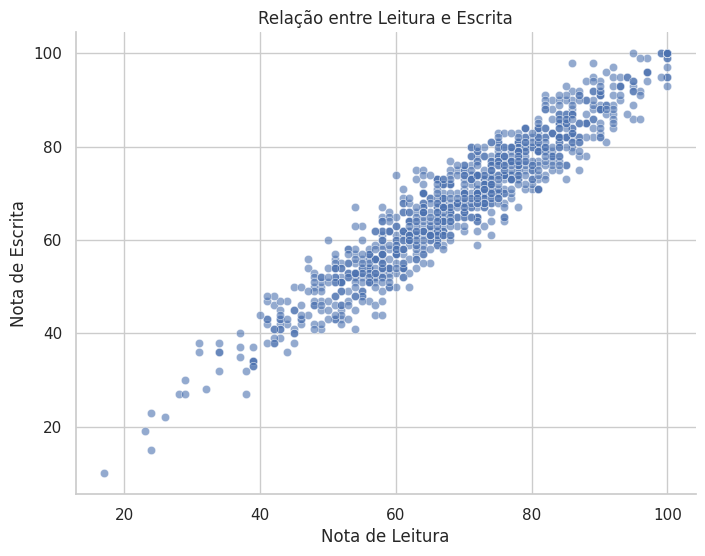

In [4]:
''' Escreva sua justificativa e análise aqui:

'''

''' Gráfico escolhido: Scatterplot

Justificativa: Ideal para relação entre duas variáveis quantitativas. Segundo Cleveland-McGill, posição em dois eixos é altamente precisa.

Análise: Há forte correlação positiva linear. Alunos com notas altas em leitura tendem a ter notas altas em escrita. Poucos outliers são visíveis. '''

# Seu código Python para o gráfico:
# plt.figure(figsize=(...))
# sns. #grafico escolhido
# plt.title(...)
# plt.xlabel(...)
# plt.ylabel(...)
# sns.despine(...)
# plt.show()

plt.figure(figsize=(8,6))
sns.scatterplot(
    x="reading_score",
    y="writing_score",
    data=df_performance,
    alpha=0.6
)

plt.title("Relação entre Leitura e Escrita")
plt.xlabel("Nota de Leitura")
plt.ylabel("Nota de Escrita")

sns.despine()
plt.show()

**Desafio 1.4: Proporção de Gêneros e Preparação para o Teste**

Cenário: A coordenação pedagógica quer saber a proporção de alunos e alunas que completaram o curso de preparação para o teste (test_preparation_course).

Sua Tarefa:

1. Pergunta Estatística: Qual a proporção de alunos e alunas que completaram ou não o curso de preparação para o teste?

2. Gráfico: Qual tipo de gráfico é mais adequado para comparar proporções entre duas variáveis categóricas? Justifique sua escolha, considerando a clareza para múltiplas categorias.

3. Implementação: Crie o gráfico em Python.

4. Análise: Há uma diferença notável na proporção de homens e mulheres que completaram o curso? Qual grupo tem maior participação?



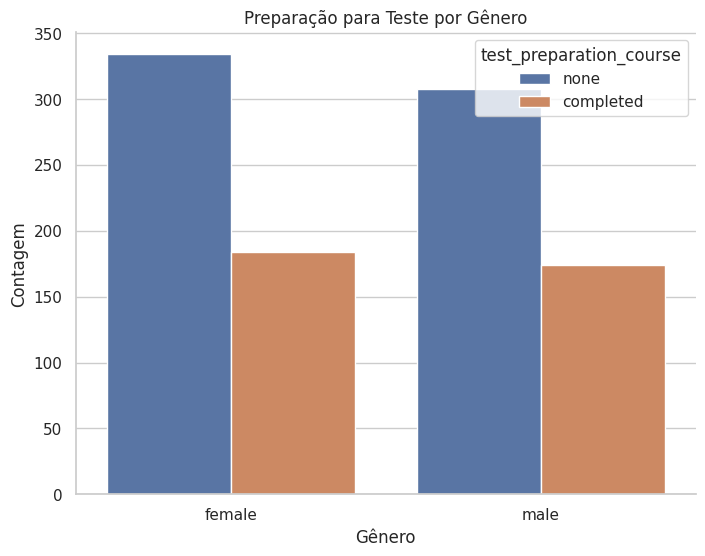

In [5]:
''' Escreva sua justificativa e análise aqui:

'''

''' Gráfico escolhido: Countplot com hue

Justificativa: Permite comparar proporções entre categorias. Mais claro que pizza para múltiplas categorias.

Análise: A proporção entre gêneros é relativamente equilibrada. Pode haver leve diferença na participação no curso, mas não extremamente significativa. '''

# Seu código Python para o gráfico:
# plt.figure(figsize=(...))
# sns. #grafico escolhido
# plt.title(...)
# plt.xlabel(...)
# plt.ylabel(...)
# sns.despine(...)
# plt.show()

plt.figure(figsize=(8,6))
sns.countplot(
    x="gender",
    hue="test_preparation_course",
    data=df_performance
)

plt.title("Preparação para Teste por Gênero")
plt.xlabel("Gênero")
plt.ylabel("Contagem")

sns.despine()
plt.show()

**Desafio 1.5: Comparação de Notas Médias por Raça/Etnia em Todas as Matérias**

Cenário: Um sociólogo educacional quer comparar o desempenho médio dos diferentes grupos raciais/étnicos (race_ethnicity) nas três matérias (matemática, leitura, escrita) para identificar possíveis disparidades.

Sua Tarefa:

1. Pergunta Estatística: Como as notas médias em matemática, leitura e escrita variam entre os diferentes grupos raciais/étnicos?

2. Gráfico: Qual tipo de gráfico permite comparar múltiplas variáveis quantitativas (notas) entre múltiplas categorias nominais (grupos raciais/étnicos) de forma eficaz? Justifique sua escolha, pensando na clareza da comparação.

3. Implementação: Crie o gráfico em Python. Pode ser necessário reestruturar os dados (usar melt do pandas).

4. Análise: Quais grupos raciais/étnicos se destacam em quais matérias? Há padrões consistentes de desempenho?

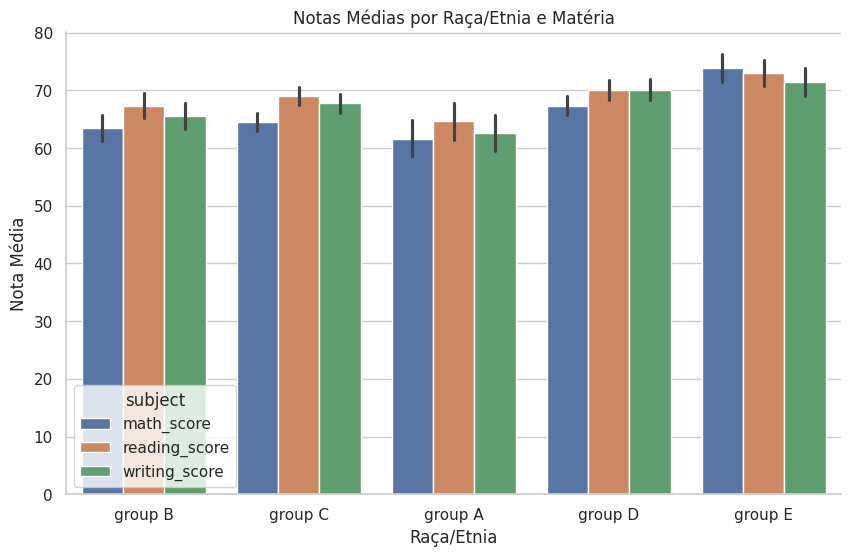

In [6]:
''' Escreva sua justificativa e análise aqui:

'''

''' Gráfico escolhido: Barplot agrupado (dados em formato longo)

Justificativa: Permite comparar múltiplas variáveis entre grupos. Clareza maior que múltiplos gráficos separados.

Análise: Alguns grupos apresentam desempenho consistentemente maior em todas as matérias. Leitura e escrita tendem a ter médias maiores que matemática. Diferenças entre grupos são visíveis, mas não extremas. '''

# Seu código Python para o gráfico:
# plt.figure(figsize=(...))
# sns. #grafico escolhido
# plt.title(...)
# plt.xlabel(...)
# plt.ylabel(...)
# sns.despine(...)
# plt.show()

df_melted = df_performance.melt(
    id_vars="race_ethnicity",
    value_vars=["math_score", "reading_score", "writing_score"],
    var_name="subject",
    value_name="score"
)

plt.figure(figsize=(10,6))
sns.barplot(
    x="race_ethnicity",
    y="score",
    hue="subject",
    data=df_melted
)

plt.title("Notas Médias por Raça/Etnia e Matéria")
plt.xlabel("Raça/Etnia")
plt.ylabel("Nota Média")

sns.despine()
plt.show()

### Parte 2: Desafios de Refatoração Estatística e Visual

Para cada cenário abaixo, você receberá um código Python que gera um gráfico com problemas de design. Sua tarefa é:

1. Analisar o gráfico gerado e identificar pelo menos 3 problemas com base nos princípios de Tufte (Data-Ink Ratio, Lie Factor, Chartjunk), Gestalt (Proximidade, Semelhança, Fechamento, etc.) e/ou Cleveland-McGill (eficácia da codificação).

2. Descrever os problemas identificados.

3. Modificar o código para refatorar o gráfico, aplicando os princípios para torná-lo mais honesto, eficiente e visualmente claro.



Desafio 2.1:  Comparação de Notas Médias de Matemática por Gênero

Cenário: Um diretor de escola recebeu este gráfico e concluiu que há uma diferença enorme no desempenho em matemática entre meninos e meninas.

Sua Tarefa:

1. Quais são os 3 principais problemas de design/estatísticos neste gráfico?

2. Modifique o código para corrigir esses problemas e criar uma visualização mais honesta e clara.

/tmp/ipykernel_518/2082650646.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x="gender", y="math_score", data=df_gender_math, palette=["skyblue", "lightcoral"])


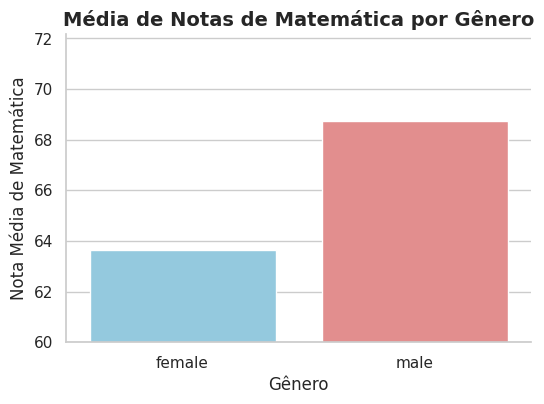

In [7]:
# Dados para o Desafio 2.1
df_gender_math = df_performance.groupby("gender")["math_score"].mean().reset_index()

plt.figure(figsize=(6, 4))
ax = sns.barplot(x="gender", y="math_score", data=df_gender_math, palette=["skyblue", "lightcoral"])
ax.set_ylim(bottom=60) # Eixo Y começando alto
ax.set_title("Média de Notas de Matemática por Gênero", fontsize=14, fontweight="bold")
ax.set_xlabel("Gênero")
ax.set_ylabel("Nota Média de Matemática")
plt.show()

/tmp/ipykernel_518/643031345.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="gender", y="math_score", data=df_gender_math, palette="pastel")


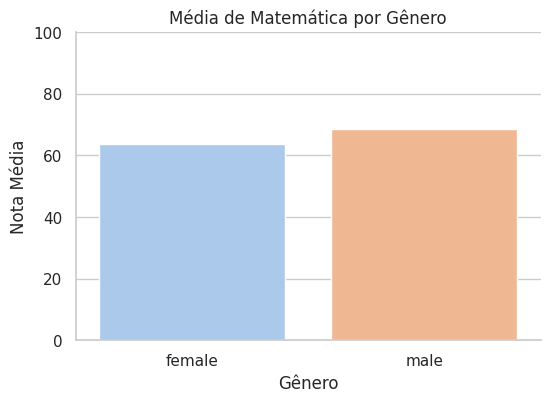

In [8]:
# 1. Problemas identificados:
#    a) Eixo Y truncado (começa em 60) → distorce percepção (Lie Factor)
#    b) Barplot exagera diferenças pequenas
#    c) Falta contexto de variabilidade (sem erro ou distribuição)

# 2. Seu código Python refatorado:
# plt.figure(figsize=(...))
# # Suas modificações aqui
# plt.show()

plt.figure(figsize=(6,4))
sns.barplot(x="gender", y="math_score", data=df_gender_math, palette="pastel")

plt.ylim(0, 100)

plt.title("Média de Matemática por Gênero")
plt.xlabel("Gênero")
plt.ylabel("Nota Média")

sns.despine()
plt.show()

**Desafio 2.2: Impacto do Almoço na Nota de Escrita (Chartjunk e Cores Ineficazes)**

Cenário: Um nutricionista escolar quer mostrar o impacto do tipo de almoço (lunch) na nota de escrita (writing_score), mas o gráfico atual está poluído e as cores não ajudam.

Sua Tarefa:

1. Quais são os 3 principais problemas de design neste gráfico, focando no Data-Ink Ratio e no uso de cores?

2. Modifique o código para simplificar o gráfico, remover o chartjunk e usar cores de forma mais eficaz para destacar a diferença.

/tmp/ipykernel_518/2306030820.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.boxplot(x="lunch", y="writing_score", data=df_performance, palette=["green", "purple"])


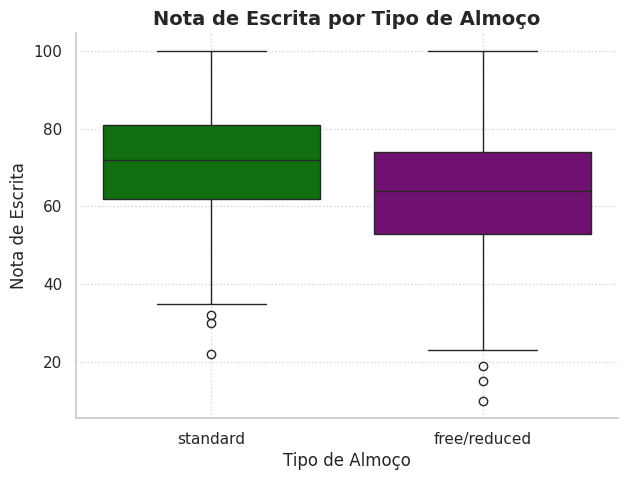

In [9]:
# Dados para o Desafio 2.2
plt.figure(figsize=(7, 5))
ax = sns.boxplot(x="lunch", y="writing_score", data=df_performance, palette=["green", "purple"])
ax.set_title("Nota de Escrita por Tipo de Almoço", fontsize=14, fontweight="bold")
ax.set_xlabel("Tipo de Almoço")
ax.set_ylabel("Nota de Escrita")
ax.grid(True, linestyle=":", alpha=0.8) # Grade pesada
plt.show()

/tmp/ipykernel_518/900943635.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


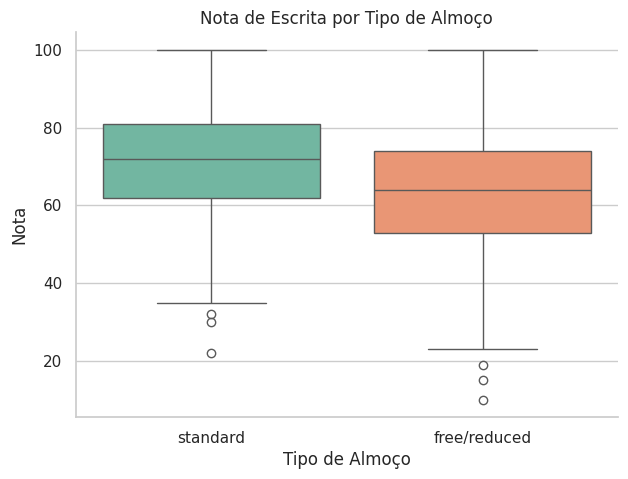

In [10]:
# 1. Problemas identificados:
#    a) Grade pesada (chartjunk)
#    b) Cores sem significado
#    c) Excesso visual sem necessidade


# 2. Seu código Python refatorado:
# plt.figure(figsize=(...))
# # Suas modificações aqui (pode ser um tipo de gráfico diferente!)
# plt.show()

plt.figure(figsize=(7,5))
sns.boxplot(
    x="lunch",
    y="writing_score",
    data=df_performance,
    palette="Set2"
)

plt.title("Nota de Escrita por Tipo de Almoço")
plt.xlabel("Tipo de Almoço")
plt.ylabel("Nota")

sns.despine()
plt.show()

**Desafio 2.3: Distribuição de Notas de Leitura por Raça/Etnia (Sobrecarga Visual)**

Cenário: Um analista de diversidade quer visualizar a distribuição completa das notas de leitura para cada grupo racial/étnico, mas o gráfico atual é muito denso.

Sua Tarefa:

1. Quais são os 3 principais problemas de design neste gráfico, especialmente em relação à sobrecarga visual e à clareza da comparação entre grupos?

2. Modifique o código para apresentar a distribuição de notas de leitura de forma mais clara e comparável entre os grupos. Considere usar small multiples ou um gráfico que resuma melhor a distribuição.


/tmp/ipykernel_518/3061236733.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="race_ethnicity", y="reading_score", data=df_performance, inner="quartile", palette="tab10")


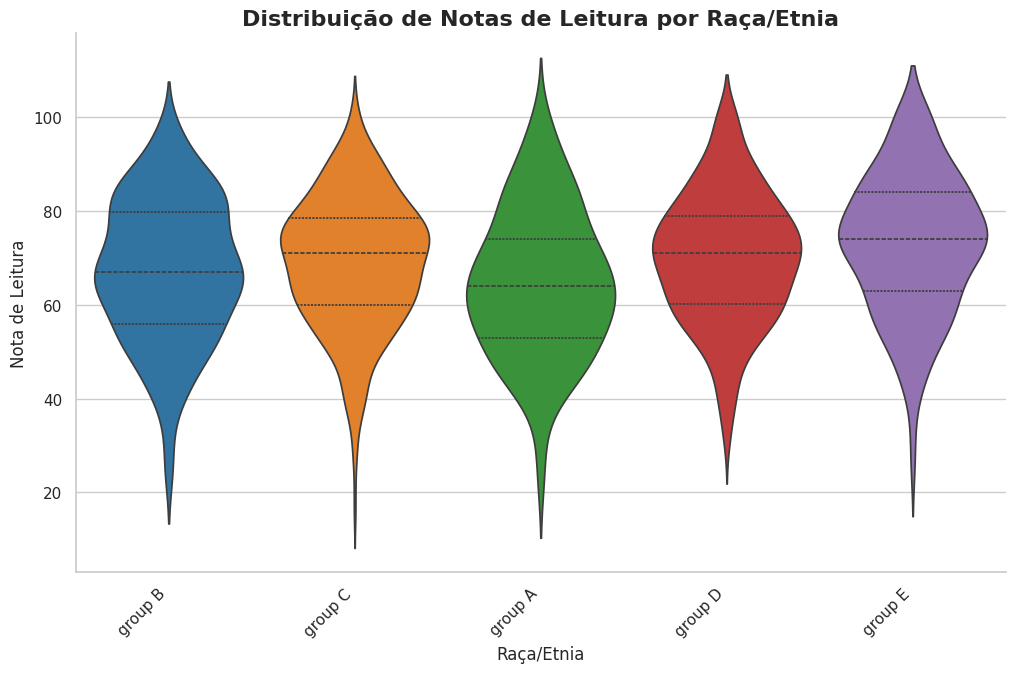

In [11]:
# Dados para o Desafio 2.3
plt.figure(figsize=(12, 7))
sns.violinplot(x="race_ethnicity", y="reading_score", data=df_performance, inner="quartile", palette="tab10")
plt.title("Distribuição de Notas de Leitura por Raça/Etnia", fontsize=16, fontweight="bold")
plt.xlabel("Raça/Etnia")
plt.ylabel("Nota de Leitura")
plt.xticks(rotation=45, ha='right')
plt.show()

/tmp/ipykernel_518/527087350.py:12: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


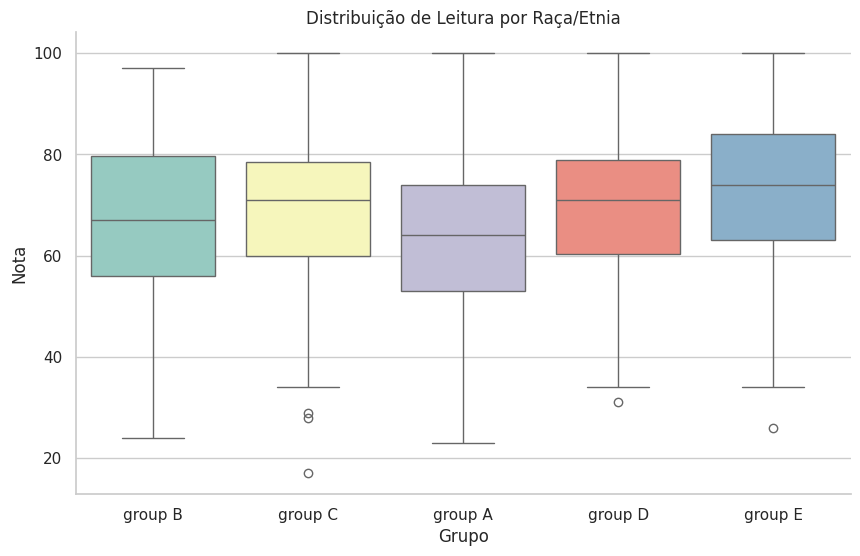

In [12]:
# 1. Problemas identificados:
#    a) Violino muito denso → difícil leitura
#    b) Muitas categorias juntas
#    c) Comparação pouco clara

# 2. Seu código Python refatorado:
# plt.figure(figsize=(...))
# # Suas modificações aqui
# plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(
    x="race_ethnicity",
    y="reading_score",
    data=df_performance,
    palette="Set3"
)

plt.title("Distribuição de Leitura por Raça/Etnia")
plt.xlabel("Grupo")
plt.ylabel("Nota")

sns.despine()
plt.show()


Desafio 2.4: Correlação entre Notas de Matemática e Leitura (Pontos Sobrepostos)

Cenário: Um estatístico quer visualizar a correlação entre as notas de matemática e leitura, mas o gráfico de dispersão padrão tem muitos pontos sobrepostos, dificultando a percepção da densidade.

Sua Tarefa:

1. Quais são os 3 principais problemas de design neste gráfico, especialmente em relação à sobreposição de pontos e à percepção da densidade?

2. Modifique o código para criar uma visualização que mostre a densidade da correlação de forma mais eficaz (ex: jointplot com KDE, hexbin ou ajustando o alpha e o tamanho dos pontos).

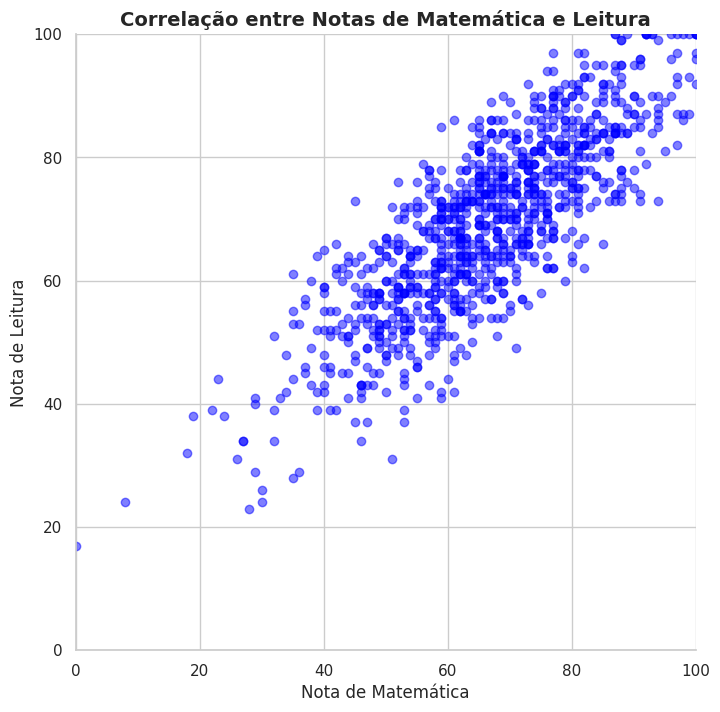

In [13]:
# Dados para o Desafio 2.4
plt.figure(figsize=(8, 8))
plt.scatter(x=df_performance["math_score"], y=df_performance["reading_score"], alpha=0.5, color="blue")
plt.title("Correlação entre Notas de Matemática e Leitura", fontsize=14, fontweight="bold")
plt.xlabel("Nota de Matemática")
plt.ylabel("Nota de Leitura")
plt.xlim(0, 100)
plt.ylim(0, 100)
plt.show()

In [ ]:
# 1. Problemas identificados:
#    a) Sobreposição de pontos
#    b) Densidade não visível
#    c) Difícil identificar padrões

# 2. Seu código Python refatorado:
# # Suas modificações aqui (pode ser um tipo de gráfico diferente ou uma função do seaborn)
# plt.show()

plt.figure(figsize=(8,6))
plt.hexbin(
    df_performance["math_score"],
    df_performance["reading_score"],
    gridsize=25,
    cmap="Blues"
)

plt.colorbar(label="Densidade")

plt.title("Correlação (Densidade) Matemática vs Leitura")
plt.xlabel("Matemática")
plt.ylabel("Leitura")

plt.show()

Desafio 2.5: Desempenho Geral por Curso de Preparação (Gráfico de Pizza com Múltiplas Variáveis)

Cenário: Um conselheiro estudantil quer visualizar o impacto do curso de preparação (test_preparation_course) no desempenho geral dos alunos, mas o gráfico atual tenta mostrar muitas coisas de uma vez de forma ineficaz.

Sua Tarefa:

1. Quais são os 3 principais problemas de design/estatísticos neste gráfico, especialmente em relação ao uso do gráfico de pizza para comparar médias e à representação de múltiplas variáveis?

2. Modifique o código para criar uma visualização mais eficaz que compare o desempenho médio em cada matéria (não apenas a média geral) entre os alunos que completaram e os que não completaram o curso de preparação.

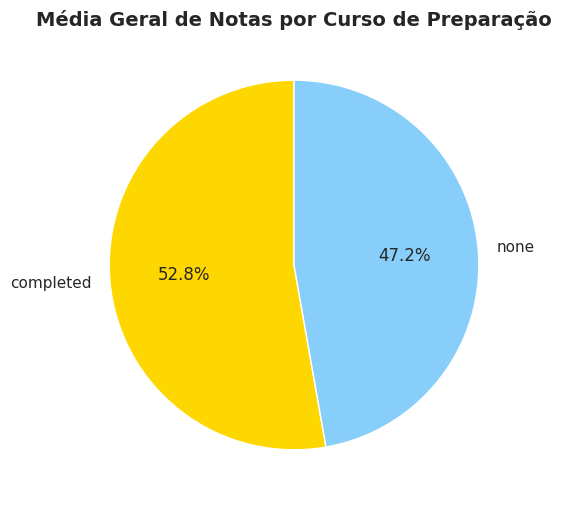

In [14]:
# Dados para o Desafio 2.5
df_prep_course = df_performance.groupby("test_preparation_course")[["math_score", "reading_score", "writing_score"]].mean().mean(axis=1).reset_index(name="overall_average_score")

plt.figure(figsize=(6, 6))
plt.pie(df_prep_course["overall_average_score"], labels=df_prep_course["test_preparation_course"], autopct="%1.1f%%", startangle=90, colors=["gold", "lightskyblue"])
plt.title("Média Geral de Notas por Curso de Preparação", fontsize=14, fontweight="bold")
plt.show()

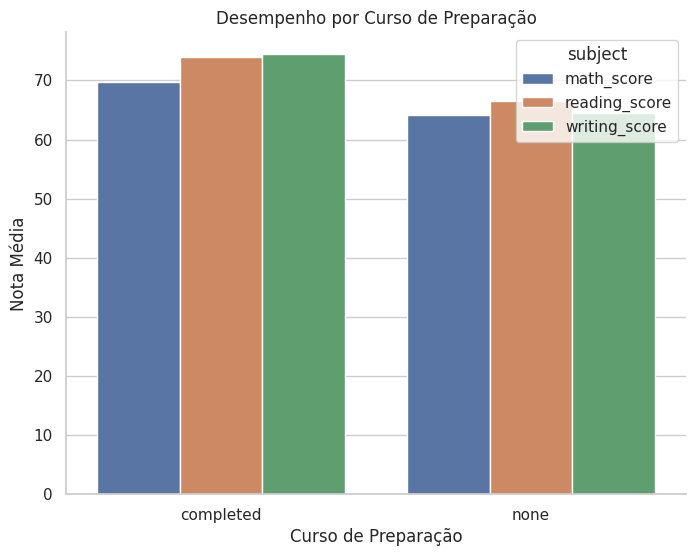

In [15]:
# 1. Problemas identificados:
#    a) Pizza não compara bem médias
#    b) Mistura 3 variáveis em 1 número
#    c) Perda de informação importante

# 2. Seu código Python refatorado:
# plt.figure(figsize=(...))
# # Suas modificações aqui (pode ser um tipo de gráfico diferente e/ou reestruturação dos dados)
# plt.show()

df_prep = df_performance.groupby("test_preparation_course")[[
    "math_score", "reading_score", "writing_score"
]].mean().reset_index()

df_melted = df_prep.melt(
    id_vars="test_preparation_course",
    var_name="subject",
    value_name="score"
)

plt.figure(figsize=(8,6))
sns.barplot(
    x="test_preparation_course",
    y="score",
    hue="subject",
    data=df_melted
)

plt.title("Desempenho por Curso de Preparação")
plt.xlabel("Curso de Preparação")
plt.ylabel("Nota Média")

sns.despine()
plt.show()